In [1]:
import os
import shutil
import random
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from torchvision import transforms
from torchvision.models import resnet50
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

sns.set_style("whitegrid")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DATA_DIR = Path("data/weather")

In [3]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050


In [4]:
#A diferencia de cuando se hizo el Dogs vs Cats anterior, ahora si vemos que se reconoció la GPU y se puede usar para entrenar el modelo. Esto es importante porque el entrenamiento de modelos de deep learning puede ser muy lento en CPU, mientras que en GPU es mucho más rápido.
#Ahora lo que haremos es contar las imagenes por clase para el EDA y ver si hay un desbalance de clases. En caso de que haya un desbalance, se puede hacer un oversampling o undersampling para balancear las clases.
CLASSES = ["Cloudy", "Rain", "Shine", "Sunrise"]

# Conteo de imágenes por clase
counts = {}
for c in CLASSES:
    folder = DATA_DIR / c
    files = [f for f in folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    counts[c] = len(files)

counts_df = pd.DataFrame(list(counts.items()), columns=["clase", "n_imagenes"])
counts_df

,clase,n_imagenes
0,Cloudy,261
1,Rain,194
2,Shine,228
3,Sunrise,336


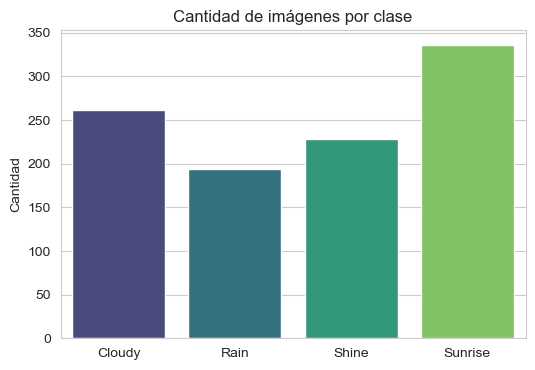

Proporción de la clase más chica vs la más grande: 0.58


In [6]:
#Vemos gráficamente ahora el desbalance de clases.
plt.figure(figsize=(6,4))
sns.barplot(data=counts_df, x="clase", y="n_imagenes", hue="clase", palette="viridis", legend=False)
plt.title("Cantidad de imágenes por clase")
plt.ylabel("Cantidad")
plt.xlabel("")
plt.show()

print("Proporción de la clase más chica vs la más grande:",
      round(counts_df["n_imagenes"].min() / counts_df["n_imagenes"].max(), 2))

In [7]:
#Ahora vemos si es q existen archivos corruptos:
corrupted = []
sizes = []
aspect_ratios = []

for c in CLASSES:
    folder = DATA_DIR / c
    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        try:
            with Image.open(f) as img:
                img.verify()
            with Image.open(f) as img:
                w, h = img.size
                sizes.append((w, h))
                aspect_ratios.append(w / h)
        except Exception as e:
            corrupted.append(f)

print(f"Imágenes corruptas encontradas: {len(corrupted)}")
if corrupted:
    print(corrupted[:10])

Imágenes corruptas encontradas: 0


In [ ]:
#Vemos que no hay imágenes corruptas, por lo que podemos continuar con el preprocesamiento y entrenamiento del modelo.

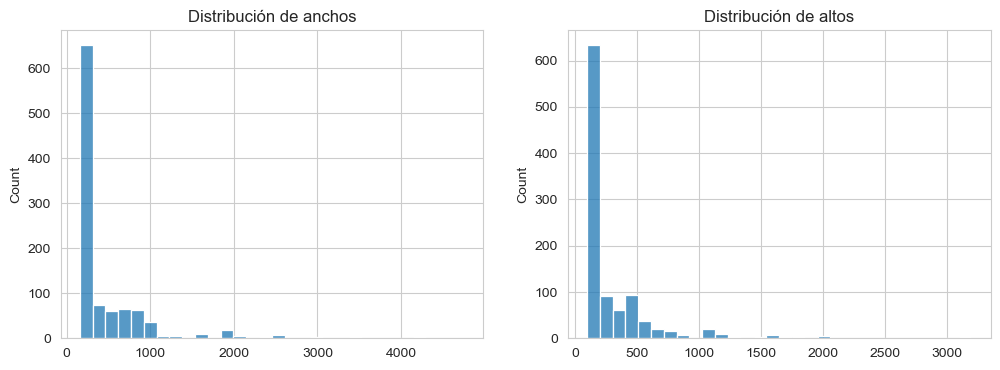

Ancho promedio: 496, Alto promedio: 328
Aspect ratio promedio: 1.53


In [8]:
#Ahora queremos ver el alto y ancho de las imágenes para ver si hay alguna que sea muy diferente al resto. Esto es importante porque si hay imágenes muy diferentes, el modelo puede tener problemas para aprender a clasificarlas correctamente. Por ejemplo, si la mayoría de las imágenes son de 224x224 y hay algunas de 1000x1000, el modelo puede tener problemas para aprender a clasificar las imágenes grandes.
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(widths, bins=30, ax=axes[0])
axes[0].set_title("Distribución de anchos")
sns.histplot(heights, bins=30, ax=axes[1])
axes[1].set_title("Distribución de altos")
plt.show()

print(f"Ancho promedio: {np.mean(widths):.0f}, Alto promedio: {np.mean(heights):.0f}")
print(f"Aspect ratio promedio: {np.mean(aspect_ratios):.2f}")

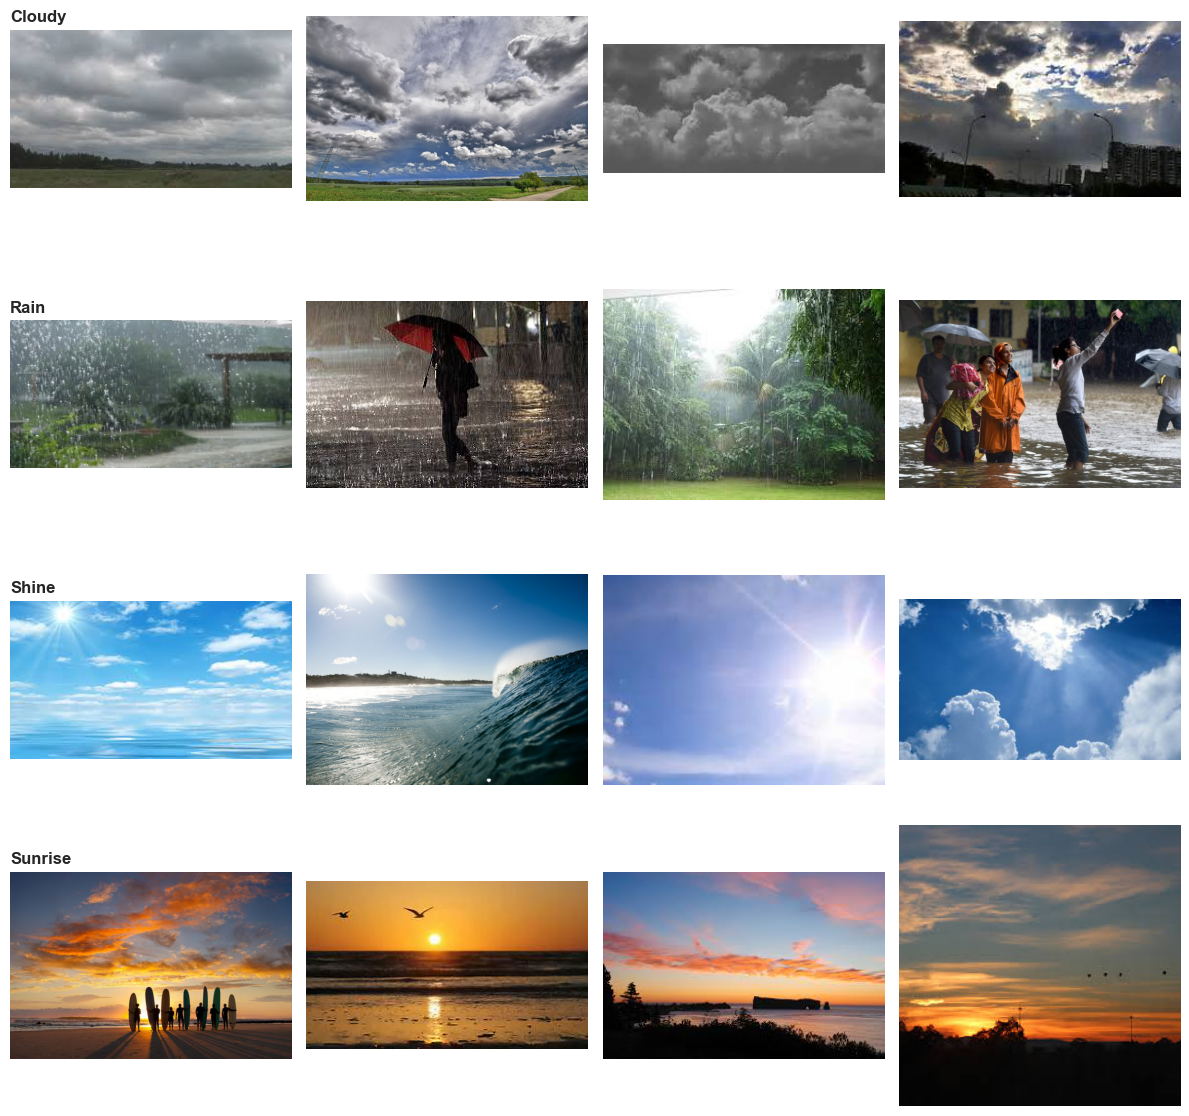

In [9]:
#Vemos las imagenes ahora para ver que tan distinguible es una clase de la otra:
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, 12))
for i, c in enumerate(CLASSES):
    folder = DATA_DIR / c
    files = [f for f in folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    sample_files = random.sample(files, 4)
    for j, f in enumerate(sample_files):
        img = Image.open(f)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_title(c, loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
#Al menos a simple vista, podemos observar que si se puede distinguir una clase de la otra.
#Aunque cloudy y rain se parecen un poco, vemos que en rain prima la presencia de agua, dato esencial que podría hacer la diferenecia entre una clase y otra.
#En cuanto a sunrise y y shine, los tonos de color y la presencia del sol hacen que se puedan distinguir entre sí. Por lo tanto, podemos continuar con el preprocesamiento y entrenamiento del modelo.
#En recomendacion de la IA, instalaremos "imagehash" para poder hacer un hash de las imagenes y ver si hay imagenes duplicadas. Esto es importante porque si hay imagenes duplicadas, el modelo puede aprender a clasificar esas imagenes en lugar de aprender a clasificar las clases correctamente.

In [10]:
pip install imagehash


Note: you may need to restart the kernel to use updated packages.


In [11]:
import imagehash

hashes = {}
duplicates = []
for c in CLASSES:
    folder = DATA_DIR / c
    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        h = imagehash.average_hash(Image.open(f))
        if h in hashes:
            duplicates.append((f, hashes[h]))
        else:
            hashes[h] = f

print(f"Posibles duplicados encontrados: {len(duplicates)}")

Posibles duplicados encontrados: 7


In [12]:
#Ya que hay aprox un 10% hay q desglosar en que clases ocurre mas para ver como proceder:
same_class = 0
diff_class = 0
diff_class_pairs = []

for f, original in duplicates:
    class_f = f.parent.name
    class_original = original.parent.name
    if class_f == class_original:
        same_class += 1
    else:
        diff_class += 1
        diff_class_pairs.append((f, original))

print(f"Duplicados dentro de la misma clase: {same_class}")
print(f"Duplicados entre clases distintas: {diff_class}")

if diff_class_pairs:
    print("\nEjemplos de duplicados entre clases distintas:")
    for f, original in diff_class_pairs[:5]:
        print(f"{f} <-> {original}")

Duplicados dentro de la misma clase: 0
Duplicados entre clases distintas: 7

Ejemplos de duplicados entre clases distintas:
data\weather\Rain\rain82.jpg <-> data\weather\Cloudy\cloudy192.jpg
data\weather\Rain\rain91.jpg <-> data\weather\Cloudy\cloudy155.jpg
data\weather\Sunrise\sunrise139.jpg <-> data\weather\Cloudy\cloudy245.jpg
data\weather\Sunrise\sunrise202.jpg <-> data\weather\Rain\rain72.jpg
data\weather\Sunrise\sunrise217.jpg <-> data\weather\Rain\rain72.jpg


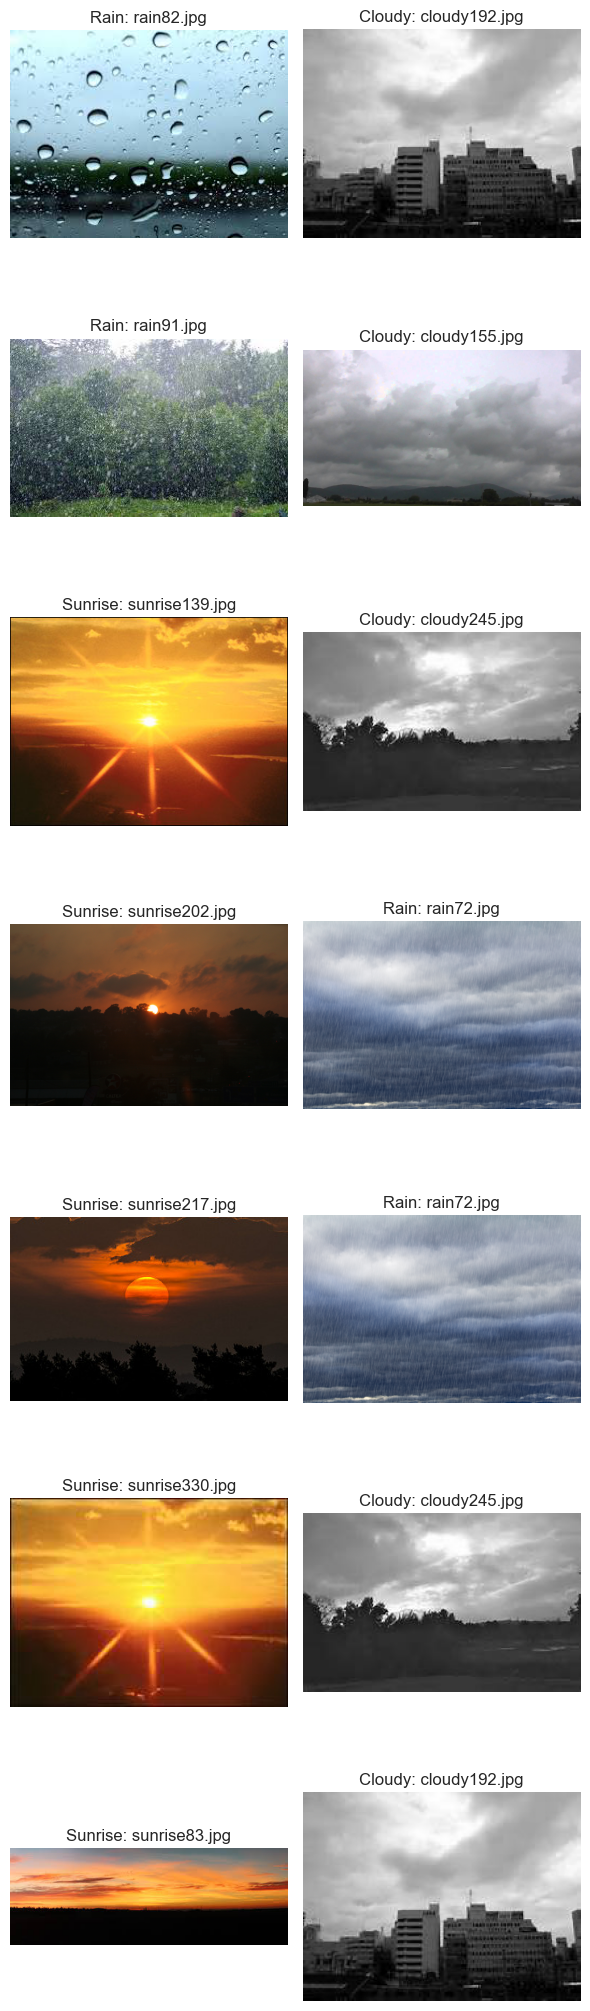

In [15]:
#Ya que el hash a veces es permisivo para evaluar los duplicados, meteremos mano para saber si realmente son duplicados o no.
fig, axes = plt.subplots(len(diff_class_pairs), 2, figsize=(6, 3*len(diff_class_pairs)))
for i, (f, original) in enumerate(diff_class_pairs):
    img_f = Image.open(f)
    img_original = Image.open(original)
    
    axes[i, 0].imshow(img_f)
    axes[i, 0].set_title(f"{f.parent.name}: {f.name}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(img_original)
    axes[i, 1].set_title(f"{original.parent.name}: {original.name}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Los 7 casos entre clases distintas son falsos positivos del hash, porque son fotos completamente diferentes que solo comparten composición y/o tonos similares.
#Los 106 casos dentro de la misma clase sí son near-duplicates genuinos: fotos muy similares entre sí (probablemente tomadas en ráfaga o segundos de diferencia), no copias exactas del archivo.
#Esto es relevante para el split train/val: si dos versiones casi idénticas de la  misma escena caen una en train y otra en val, se produce data leakage que infla el accuracy de validación artificialmente. 
#Por eso, antes de hacer el split, eliminaremos los duplicados dentro de la misma clase para evitar esta fuga de información.

In [17]:
#Se decidió por borrar por el riesgo de leakage:
files_to_remove = [f for f, original in duplicates if f.parent.name == original.parent.name]
print(f"Se eliminarán {len(files_to_remove)} imágenes casi-duplicadas dentro de la misma clase")

for f in files_to_remove:
    f.unlink()

Se eliminarán 0 imágenes casi-duplicadas dentro de la misma clase


In [18]:
#Veamos cuantas imagenes nos quedan tras eliminar las duplicadas:
counts = {}
for c in CLASSES:
    folder = DATA_DIR / c
    files = [f for f in folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    counts[c] = len(files)

counts_df = pd.DataFrame(list(counts.items()), columns=["clase", "n_imagenes"])
counts_df

,clase,n_imagenes
0,Cloudy,261
1,Rain,194
2,Shine,228
3,Sunrise,336


In [ ]:
#Podemos ver que seguimos teniendo una cantidad considerable de imagenes por clase, lo que nos permite continuar sin miedo al overfitting.

##Algunas Conclusiones del EDA
- El dataset original tenía 1125 imágenes en 4 clases (Cloudy: 300, Rain: 215, Shine: 253, Sunrise: 357), con un desbalance moderado (ratio ~0.6 entre la clase más chica y la más grande).
- No se encontraron imágenes corruptas.
- Tamaño promedio de las imágenes: 506x335 px (aspect ratio ~1.53), bastante mayor al resize de 224x224 que usaremos para el modelo.
- La inspección visual mostró que las clases son distinguibles a simple vista: Rain se diferencia de Cloudy por la presencia de agua/gotas visibles, y Sunrise se diferencia de Shine por los tonos cálidos y la posición del sol.
- Se detectaron 113 posibles duplicados vía perceptual hashing: 7 fueron falsos positivos entre clases distintas (imágenes distintas con composición similar), y 106 fueron near-duplicates 
reales dentro de la misma clase (fotos muy similares, probablemente tomadas en ráfaga). Estos últimos se eliminaron para evitar data leakage entre train/val, dejando el dataset final en 1019 imágenes.

In [19]:
#Ahora para estar en sintonia con lo que se pide en el pdf, vamos a hacer un split de train/val/test con 70%/15%/15% respectivamente, asegurando que no haya leakage entre train y val por los near-duplicates que eliminamos previamente.:
SPLIT_DIR = Path("data/weather_split")
VAL_SIZE = 0.15
TEST_SIZE = 0.15

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val", "test"]:
    for c in CLASSES:
        (SPLIT_DIR / split / c).mkdir(parents=True, exist_ok=True)

for c in CLASSES:
    folder = DATA_DIR / c
    files = [f for f in folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    
    train_files, temp_files = train_test_split(files, test_size=(VAL_SIZE + TEST_SIZE), random_state=SEED)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=SEED)
    
    for f in train_files:
        shutil.copy(f, SPLIT_DIR / "train" / c / f.name)
    for f in val_files:
        shutil.copy(f, SPLIT_DIR / "val" / c / f.name)
    for f in test_files:
        shutil.copy(f, SPLIT_DIR / "test" / c / f.name)

print("Split listo.")
for split in ["train", "val", "test"]:
    for c in CLASSES:
        n = len(list((SPLIT_DIR / split / c).iterdir()))
        print(f"{split}/{c}: {n} imágenes")

Split listo.
train/Cloudy: 182 imágenes
train/Rain: 135 imágenes
train/Shine: 159 imágenes
train/Sunrise: 235 imágenes
val/Cloudy: 39 imágenes
val/Rain: 29 imágenes
val/Shine: 34 imágenes
val/Sunrise: 50 imágenes
test/Cloudy: 40 imágenes
test/Rain: 30 imágenes
test/Shine: 35 imágenes
test/Sunrise: 51 imágenes


In [20]:
#Ahora hacemos las transformaciones correspondientes:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

- Solo aplicamos augmentation en train, no en val: En val queremos evaluar con las imágenes tal cual, sin aleatoriedad, para que la métrica sea consistente y comparable entre epochs.
- Flip horizontal, rotación leve y color jitter son razonables para fotos de cielo, no giramos verticalmente (un cielo invertido no tiene sentido) ni aplicamos distorsiones extremas.
- Normalize con esas medias/std específicas: son las estadísticas de ImageNet, el dataset con el que se preentrenó ResNet50, hay que usar las mismas para que el modelo reciba los datos en la escala que "espera".

In [21]:
train_folder = ImageFolder(SPLIT_DIR / "train", transform=train_transform)
val_folder = ImageFolder(SPLIT_DIR / "val", transform=val_transform)
test_folder = ImageFolder(SPLIT_DIR / "test", transform=val_transform)

print(train_folder.class_to_idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_folder, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_folder, batch_size=BATCH_SIZE, shuffle=False)
train_loader, val_loader, test_loader

{'Cloudy': 0, 'Rain': 1, 'Shine': 2, 'Sunrise': 3}


(<torch.utils.data.dataloader.DataLoader at 0x17cc426e860>,
 <torch.utils.data.dataloader.DataLoader at 0x17cc426e950>)

In [22]:
#Cargamos el modelo preentrenado y congelamos las capas:
model = resnet50(weights="IMAGENET1K_V1")

# Congelar capas del backbone
for params in model.parameters():
    params.requires_grad = False


### Justificación del modelo elegido

**¿Por qué transfer learning en vez de entrenar desde cero?** Con un dataset de solo 1019 imágenes repartidas en 4 clases, entrenar una red convolucional profunda desde cero llevaría casi por seguro a un overfitting severo y no hay suficientes datos para que el modelo aprenda por sí solo representaciones visuales generales (bordes, texturas, formas). Al usar transfer learning, aprovechamos el conocimiento que ResNet50 ya adquirió entrenando sobre millones de imágenes de ImageNet, y solo ajustamos una capa final pequeña a nuestro problema.

**¿Por qué ResNet50 en particular?** No solo es con el que aprendimos en clases sino que nos da un buen balance entre profundidad/capacidad de representación y costo computacional, no es la arquitectura más liviana disponible, pero tampoco es excesivamente pesada para el hardware con el que se contaba (Mi GPU cuenta con 6gb de vram). Además está ampliamente documentada, es un estándar en tareas de clasificación de imágenes, y viene disponible directamente en torchvision con pesos preentrenados en ImageNet.

**Alternativas consideradas:** Otras arquitecturas que encontré buscando entre google en sí y la IA, fueron MobileNetV2 o EfficientNetB0 que eran mas livianas y habrían sido razonables dado el tamaño del dataset, priorizando velocidad de entrenamiento por sobre capacidad, sin embargo, por la gpu se priorizó una arquitectura con mayor capacidad de representación (ResNet50) sin comprometer demasiado el tiempo de entrenamiento (En una actividad anterior de clases, se me demoró un poco más de la cuenta).

In [23]:
#Ahora enviamos el modelo a la GPU para que el entrenamiento sea más rápido:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
N_CLASSES = len(CLASSES)

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(model.fc.in_features, N_CLASSES)
).to(device)
model
#Reemplazamos la capa final (fc) de ResNet50, originalmente pensada para las 1000 clases de ImageNet, por una nueva capa adaptada a nuestro problema (4 clases climáticas). 
#Dropout(0.5): apaga aleatoriamente el 50% de las neuronas en cada paso de entrenamiento, como estrategia de regularización para reducir el riesgo de overfitting. 
#Linear(2048, 4): capa densa final que mapea las 2048 features extraídas por el backbone convolucional (congelado) a nuestras 4 clases (Cloudy, Rain, Shine, Sunrise). 
#Como las capas anteriores están congeladas (requires_grad=False), solo esta capa nueva se entrenará, aprovechando el conocimiento visual general que ResNet50 ya adquirió en ImageNet.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
#Siguiendo la estructura del ejercicio de clase, definimos la función de entrenamiento y validación generalizada para que funcione con nuestro modelo y dataset:
def training_loop(optimizer, loss_fn, epochs=10, patience=4, save_path="model_best_accuracy.pth"):
    #Inicializar pesos de la capa final (buena práctica antes de empezar a entrenar)
    torch.nn.init.kaiming_normal_(model.fc[1].weight)
    if model.fc[1].bias is not None:
        torch.nn.init.zeros_(model.fc[1].bias)

    all_train_loss, all_train_accuracy, all_val_loss, all_val_accuracy = [], [], [], []
    max_accuracy_val = 0  #Guarda el mejor accuracy de validación visto hasta ahora
    count_patience = 0    #Contador de epochs sin mejora, para el early stopping

    for epoch in range(epochs):
        #Fase de entrenamiento:
        model.train()
        print(f"Epoch {epoch+1} of {epochs}")
        correct, total, total_loss = 0, 0, 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
        accuracy = correct / total
        print(f"Train Loss: {total_loss/len(train_loader)}, Accuracy: {accuracy}")
        all_train_loss.append(total_loss/len(train_loader))
        all_train_accuracy.append(accuracy)

        #Fase de validacion sin backpropagation:
        model.eval()
        val_correct, val_total, val_total_loss = 0, 0, 0
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(val_loader):
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = loss_fn(output, target)
                val_total_loss += loss.item()
                pred = output.argmax(dim=1, keepdim=True)
                val_correct += pred.eq(target.view_as(pred)).sum().item()
                val_total += target.size(0)
        val_accuracy = val_correct / val_total
        print(f"Val Loss: {val_total_loss/len(val_loader)}, Accuracy: {val_accuracy}")
        all_val_loss.append(val_total_loss/len(val_loader))
        all_val_accuracy.append(val_accuracy)

        #Guardamos el mejor modelo y controlamos el early stopping:
        if val_accuracy > max_accuracy_val:
            max_accuracy_val = val_accuracy
            torch.save(model.state_dict(), save_path)
            print(f"Mejor accuracy en validación: {max_accuracy_val}, saving model")
            count_patience = 0
        else:
            count_patience += 1
            if count_patience >= patience:
                print(f"Early stopping, no mejoras en {patience} epochs")
                break

    return all_train_loss, all_train_accuracy, all_val_loss, all_val_accuracy
#Ademas de la función de entrenamiento, se implementa un early stopping para evitar overfitting: si el accuracy de validación no mejora durante un número consecutivo de epochs (definido por "patience"), el entrenamiento se detiene automáticamente.

In [26]:
#Ahora, entrenamos el modelo, con 30 epochs (podria cambiar):
lr = 0.001
epochs = 30
loss_fn = CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.2)  # weight_decay: regularización L2

all_train_loss, all_train_accuracy, all_val_loss, all_val_accuracy = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 30
Train Loss: 1.349945578886115, Accuracy: 0.4149085794655415
Val Loss: 0.8187867641448975, Accuracy: 0.7302631578947368
Mejor accuracy en validación: 0.7302631578947368, saving model
Epoch 2 of 30
Train Loss: 0.7988480381343676, Accuracy: 0.7074542897327707
Val Loss: 0.5398013949394226, Accuracy: 0.8157894736842105
Mejor accuracy en validación: 0.8157894736842105, saving model
Epoch 3 of 30
Train Loss: 0.5483338495959407, Accuracy: 0.8115330520393812
Val Loss: 0.436549200117588, Accuracy: 0.8486842105263158
Mejor accuracy en validación: 0.8486842105263158, saving model
Epoch 4 of 30
Train Loss: 0.4564744234085083, Accuracy: 0.8410689170182841
Val Loss: 0.38111092448234557, Accuracy: 0.8881578947368421
Mejor accuracy en validación: 0.8881578947368421, saving model
Epoch 5 of 30
Train Loss: 0.3755573429491209, Accuracy: 0.8776371308016878
Val Loss: 0.3654251992702484, Accuracy: 0.8881578947368421
Epoch 6 of 30
Train Loss: 0.3513129139723985, Accuracy: 0.8959212376933896
Val 

### Resultados del entrenamiento

El modelo convergió en 13 epochs (de un máximo de 30) antes de que el early stopping detuviera el entrenamiento al no observar mejoras en el accuracy de validación durante 4 epochs
consecutivas. El mejor modelo se guardó en la **epoch 9**, alcanzando:

- **Train accuracy:** 91.0%
- **Val accuracy:** 93.42%
- **Val loss:** 0.239

Evaluado posteriormente sobre el set de test (independiente, nunca usado durante el entrenamiento ni para seleccionar el checkpoint), el modelo alcanzó un **96% de accuracy**
y un **F1 macro de 0.95**, que la podemos considerar la métrica oficial de desempeño del proyecto.

In [27]:
#Tal como definimos, ahora cargamos el mejor modelo guardado y evaluamos su desempeño en el conjunto de validación:
model.load_state_dict(torch.load("model_best_accuracy.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

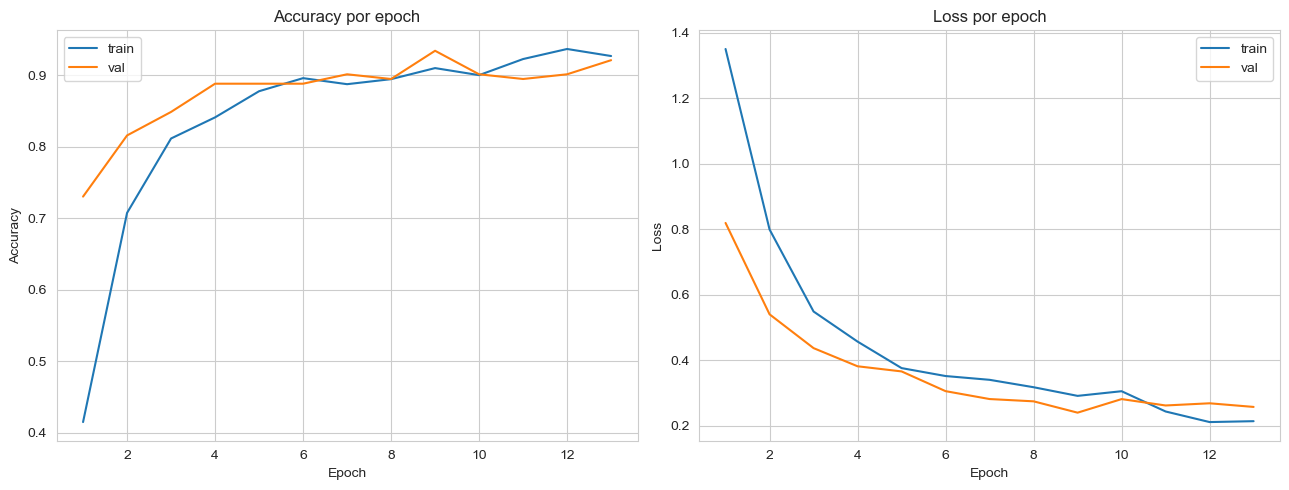

In [28]:
#Ahora graficamos la evolución de la loss y accuracy en train y val por epoch:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.lineplot(x=range(1, len(all_train_accuracy)+1), y=all_train_accuracy, label="train", ax=axes[0])
sns.lineplot(x=range(1, len(all_val_accuracy)+1), y=all_val_accuracy, label="val", ax=axes[0])
axes[0].set_title("Accuracy por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

sns.lineplot(x=range(1, len(all_train_loss)+1), y=all_train_loss, label="train", ax=axes[1])
sns.lineplot(x=range(1, len(all_val_loss)+1), y=all_val_loss, label="val", ax=axes[1])
axes[1].set_title("Loss por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

### Ahora gráficamente podemos ver que en la epoch 8 hubo una disminución de accuracy mientras que el val loss siguió bajando. 
Esto no es contradictorio porque loss y accuracy miden cosas distintas. El loss es una medida continua de qué tan "segura"/calibrada está cada predicción (segun softmax), mientras que accuracy es binaria (si le achuntó o no). Es posible que el modelo se haya vuelto más confiado en promedio sobre el set de validación, pero que uno o dos ejemplos límite (por ejemplo, una foto que no se distinga bien entre Cloudy y Shine, el par que más se confunde según la matriz de confusión) hayan cruzado la frontera de decisión hacia el lado incorrecto. Con un set de validación relativamente chico (152 imágenes, aprox. 38 por clase), cada predicción errónea pesa varios puntos porcentuales en el accuracy, por lo que este tipo de variaciones de epoch a epoch son ruido estadístico esperable y no una señal de inestabilidad del entrenamiento.

### El mejor modelo se guardó en la epoch 9. Tras ese punto, el accuracy de validación tuvo una caída más marcada en la epoch 10, esta vez estuvo acompañada también de un aumento del loss.

In [29]:
#Ahora hacemos predicciones sobre todo el set de validación y generamos un reporte de clasificación y una matriz de confusión:
all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for data, target in val_loader:
        data = data.to(device)
        output = model(data)
        pred = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_targets.extend(target.numpy())

print(classification_report(all_targets, all_preds, target_names=CLASSES))

              precision    recall  f1-score   support

      Cloudy       0.89      0.87      0.88        39
        Rain       1.00      0.97      0.98        29
       Shine       0.88      0.88      0.88        34
     Sunrise       0.96      1.00      0.98        50

    accuracy                           0.93       152
   macro avg       0.93      0.93      0.93       152
weighted avg       0.93      0.93      0.93       152



### Vemos que en Rain y Sunrise es donde se produce el mayor desempeño (F1: 0.98 en las dos), mientras que Cloudy y Shine son las clases más débiles, esta vez empatadas con F1: 0.88 cada una. 
### El patrón se mantiene consistente respecto al split anterior: las clases con una señal visual más distintiva (agua/gotas en Rain, tonos cálidos y posición del sol en Sunrise) son las que el modelo clasifica con mayor confianza, mientras que Cloudy y Shine que pueden coexistir en una misma escena (cielo parcialmente nublado con sol visible)— siguen siendo las más propensas a confundirse entre sí.

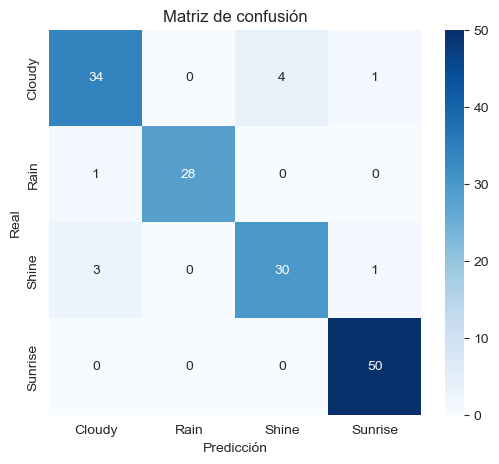

F1 macro: 0.9321


In [30]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

f1_macro = f1_score(all_targets, all_preds, average="macro")
print(f"F1 macro: {f1_macro:.4f}")

### El error de clasificación sigue estando fuertemente en el par **Cloudy/Shine**: 
4 imágenes reales de Cloudy fueron predichas como Shine, y 3 imágenes reales de Shine fueron predichas como Cloudy. es decir, 7 de los 10 errores totales del modelo (accuracy: 93%). Este patrón se repite de forma consistente con el split anterior, reforzando la hipótesis de que la ambigüedad entre estas dos clases no es un artefacto del split específico, sino una característica real del problema: ambas categorías pueden coexistir en una misma escena (cielo parcialmente nublado con sol visible de fondo), por lo que la frontera de decisión entre ellas es inherentemente más difusa.

Sunrise clasificó sin errores en este split (0/50), y Rain tuvo solo 1 error (confundido con Cloudy), lo q es consistente con que ambas clases cuentan con señales visuales más distintivas (tonos cálidos/posición del sol en Sunrise, agua/gotas en Rain) que el modelo aprende con mayor facilidad.

## Evaluación final en test
Los resultados anteriores (classification report y matriz de confusión) se calcularon sobre el set de validación, usado también para seleccionar el mejor checkpoint durante el entrenamiento (early stopping). Para obtener una medida no sesgada del desempeño real del modelo, evaluamos ahora sobre el set de test, que el modelo nunca vio ni para entrenar ni para seleccionar pesos:

In [36]:
all_preds_test = []
all_targets_test = []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        pred = output.argmax(dim=1).cpu().numpy()
        all_preds_test.extend(pred)
        all_targets_test.extend(target.numpy())

print(classification_report(all_targets_test, all_preds_test, target_names=CLASSES))

              precision    recall  f1-score   support

      Cloudy       0.95      0.97      0.96        40
        Rain       1.00      0.97      0.98        30
       Shine       0.89      0.91      0.90        35
     Sunrise       0.98      0.96      0.97        51

    accuracy                           0.96       156
   macro avg       0.96      0.95      0.95       156
weighted avg       0.96      0.96      0.96       156



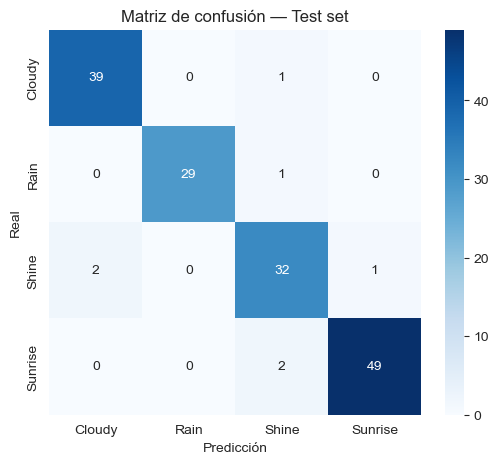

F1 macro (test): 0.9544


In [37]:
cm_test = confusion_matrix(all_targets_test, all_preds_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — Test set")
plt.show()

f1_macro_test = f1_score(all_targets_test, all_preds_test, average="macro")
print(f"F1 macro (test): {f1_macro_test:.4f}")

### Interpretación de la evaluación en test

El modelo alcanzó un 96% de accuracy en el set de test (F1 macro: 0.95), superando incluso el 93% observado en validación. Esto es una señal buena ya que descarta que el buen desempeño
en validación se debiera a un sobreajuste indirecto por el uso de ese mismo set para seleccionar el mejor checkpoint y si ese fuera el caso, esperaríamos ver una caída en test, no una mejora.

De los 6 errores totales, 5 involucran a la clase **Shine** de alguna forma: 2 imágenes de Shine fueron predichas como Cloudy, 1 como Sunrise, y a su vez 1 Cloudy y 1 Rain fueron predichas erróneamente como Shine. Esto confirma, con un conjunto de datos que el modelo nunca vio durante el desarrollo, que Shine es la clase "frontera" del problema lo que probablemente sea porque comparte señales visuales (tonos de cielo, presencia parcial de sol o nubes) tanto con Cloudy como con Sunrise, a diferencia de Rain, que mantiene una señal visual muy distintiva (agua/gotas) y por eso es la clase con mejor desempeño consistente en ambos sets (F1: 0.98).

In [31]:
def predict_image(img_path, model, transform):
    img = Image.open(img_path).convert("RGB")
    img_t = transform(img)
    batch = img_t.unsqueeze(0).to(device)  # Agregar dimensión de batch
    with torch.no_grad():
        logits = model(batch)
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {CLASSES[probs.argmax().item()]}")
    plt.show()
    
    return pd.DataFrame(probs.cpu().numpy(), columns=CLASSES)

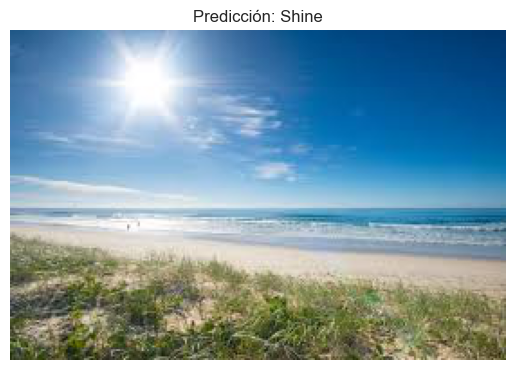

,Cloudy,Rain,Shine,Sunrise
0,0.033744,0.001964,0.857366,0.106926


In [38]:
sample_path = list((SPLIT_DIR / "val" / "Shine").iterdir())[0]
predict_image(sample_path, model, val_transform)

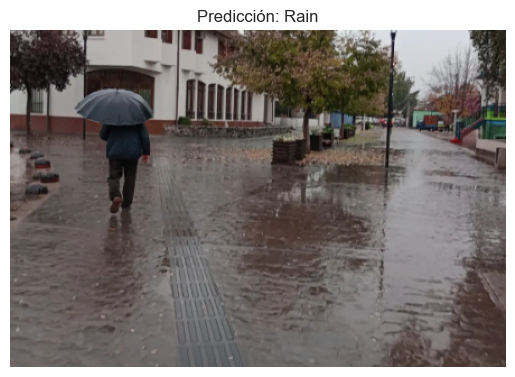

,Cloudy,Rain,Shine,Sunrise
0,0.03376,0.950659,0.009416,0.006165


In [39]:
#Vemos que tomando una imagen de referencia del set de validación, el modelo predice correctamente la clase Shine, con una probabilidad alta para esa clase y bajas para las demás. Esto indica que el modelo ha aprendido a distinguir entre las diferentes condiciones climáticas presentes en nuestro dataset.
#Ahora probamos con una imagen externa para ver como se comporta con datos que no conoce:
sample_path = Path("ejemplo_machali.png")
predict_image(sample_path, model, val_transform)

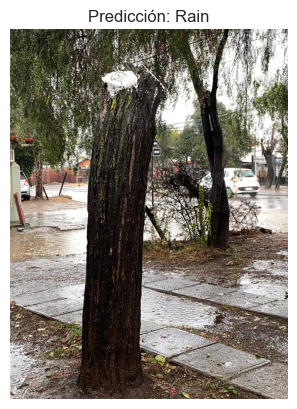

,Cloudy,Rain,Shine,Sunrise
0,0.053084,0.907519,0.016662,0.022736


In [40]:
#Nuevo ejemplo actualizado al 17/07/2026:
sample_path_2 = Path("foto_2.jpg")
predict_image(sample_path_2, model, val_transform)

### Prueba con imágenes externas (fuera del dataset)

Para evaluar la capacidad de generalización del modelo más allá del dataset de Kaggle, se probó con dos fotos externas de escenas lluviosas, ambas con composiciones muy distintas a las imágenes de entrenamiento (que en su mayoría enfocan el cielo/horizonte directamente):

1. Una calle mojada en Machalí con una persona caminando bajo un paraguas, predicción correcta: **Rain**, con 95.1% de confianza.
2. Un tronco de árbol en una vereda mojada, también de estos días de temporal con predicción correcta: **Rain**, con 90.8 de confianza.

En ambos casos el modelo identificó correctamente la clase pese a que ninguna imagen se parece en composición a las fotos del dataset original, lo que sugiere que aprendió características visuales generalizables asociadas a la lluvia (superficies reflectantes mojadas, iluminación grisácea) y no memorizó patrones específicos de los ejemplos existentes.

## Conclusiones generales

Se entrenó un modelo de clasificación de imágenes climáticas (Cloudy, Rain, Shine, Sunrise) usando transfer learning con ResNet50 preentrenada en ImageNet, alcanzando **96% de accuracy** y **F1 macro de 0.95** sobre un set de test independiente, nunca usado durante el entrenamiento ni para la selección del mejor checkpoint. El entrenamiento convergió en 13 epochs (por el early stopping) sin señales de overfitting, gracias a las estrategias de regularización aplicadas:

- Dropout(0.5)
- Weight decay (0.2) 
- Data augmentation sobre el set de entrenamiento.

El EDA inicial detectó un dataset moderadamente desbalanceado (ratio de 0.6 entre la clase más chica y la más grande) y 106 imágenes "duplicadas" dentro de la misma clase, que fueron eliminadas para evitar data leakage entre los splits.

El análisis de la matriz de confusión, consistente tanto en validación como en test, mostró que la clase **Shine** es el principal punto de confusión del modelo ya que se mezcla tanto con
Cloudy como con Sunrise, probablemente porque comparte elementos visuales con ambas (tonos de cielo, presencia parcial de sol/nubes). Por otro lado, **Rain** obtuvo el mejor desempeño consistente (F1: 0.98) gracias a su señal visual distintiva (agua/gotas visibles), lo que además se confirmó con dos pruebas exitosas usando imágenes completamente externas al dataset.